# Clustering Physical Activity

Кластеризация данных носимых устройств (PAMAP2) по типу физической активности.
Источник: три IMU (рука, грудь, лодыжка) и температурные датчики, разметки нет.
Метрика соревнования: accuracy. Решение полностью без учителя (unsupervised).

Итог: accuracy на лидерборде около 0.77. Ключевые шаги: восстановление
перемешанного временного ряда, оконные и частотные признаки, подбор числа
кластеров по лидерборду (K=7), сглаживание меток по баутам.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import (KMeans, MiniBatchKMeans,
                             AgglomerativeClustering, DBSCAN, Birch)
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score,
                             normalized_mutual_info_score)

warnings.simplefilter("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

SEED = 42
WINDOW = 256        # окно в отсчётах, около 2.5 с при 100 Гц
STRIDE = 128        # шаг частотного окна
N_CLUSTERS = 7      # подобрано по лидерборду (см. раздел 6)
MIN_LEN = 200       # минимальная длина баута при сглаживании меток
DATA_PATH = "data/monitoring_data.csv"
np.random.seed(SEED)

## 1. Загрузка и обзор данных

В файле 53 столбца: timestamp, по 17 каналов с каждого узла (рука, грудь,
лодыжка) и subject_id. Разметки активности нет, её и нужно восстановить.
Добавляем row_id (исходная позиция строки), он понадобится для сабмита,
поэтому в выводе shape столбцов на один больше.

In [2]:
df = pd.read_csv(DATA_PATH)
df = df.reset_index().rename(columns={"index": "row_id"})
print("Размер (с добавленным row_id):", df.shape)
df.head()

Размер (с добавленным row_id): (534601, 54)


,row_id,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


In [3]:
orientation = [c for c in df.columns if "Orientation" in c]
meta = ["timestamp", "subject_id", "row_id"]
sensor = [c for c in df.columns if c not in orientation + meta]

print(f"Сенсорных каналов: {len(sensor)}")
print(f"Orientation (по документации PAMAP2 невалидны): {len(orientation)}")
print(f"Испытуемых: {df['subject_id'].nunique()}")
df[sensor].describe().T[["mean", "std", "min", "max"]].head(8).round(2)

Сенсорных каналов: 39
Orientation (по документации PAMAP2 невалидны): 12
Испытуемых: 8


,mean,std,min,max
handTemperature,32.45,1.75,27.50,35.25
handAcc16_1,-4.44,7.06,-114.76,60.91
handAcc16_2,3.24,7.22,-82.55,155.53
handAcc16_3,4.08,3.83,-73.95,78.48
handAcc6_1,-4.38,7.07,-61.21,34.16
handAcc6_2,3.22,6.86,-61.82,62.26
handAcc6_3,4.26,3.82,-61.58,60.84
handGyro1,-0.01,1.16,-19.69,22.96


## 2. Разведочный анализ (EDA)

### 2.1 Пропуски

Пропуски идут блоками: если узел отключился, в строке отсутствуют сразу все
17 его каналов. Это выпадение сенсора целиком, а не отдельных значений.

Доля пропусков по узлам, %:
hand     0.76
chest    0.15
ankle    0.48


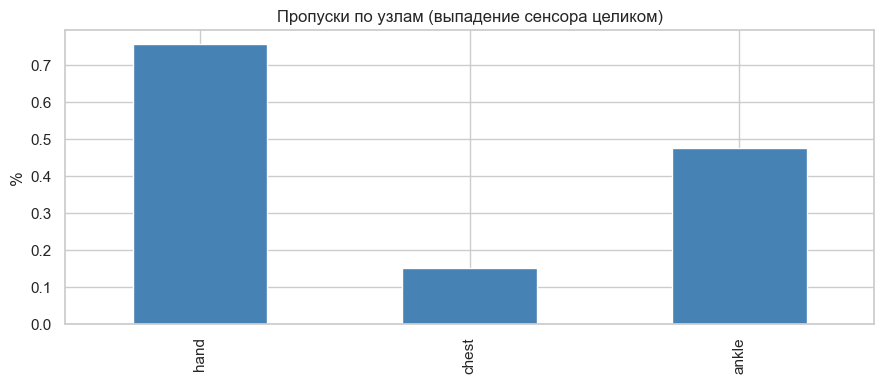

In [4]:
na = df[sensor].isna().mean().mul(100)
by_site = pd.Series({s: na[[c for c in sensor if c.startswith(s)]].mean()
                     for s in ["hand", "chest", "ankle"]})
print("Доля пропусков по узлам, %:")
print(by_site.round(2).to_string())

ax = by_site.plot.bar(color="steelblue")
ax.set(title="Пропуски по узлам (выпадение сенсора целиком)", ylabel="%")
plt.tight_layout()
plt.show()

### 2.2 Распределение по испытуемым

Восемь испытуемых, объём записей сопоставим. subject_id это служебный
столбец, в признаки кластеризации он не идёт (иначе модель делила бы людей,
а не активности), но он нужен для восстановления временного ряда. Ниже мы ещё
вернёмся к нему и проверим признаки на утечку испытуемого.

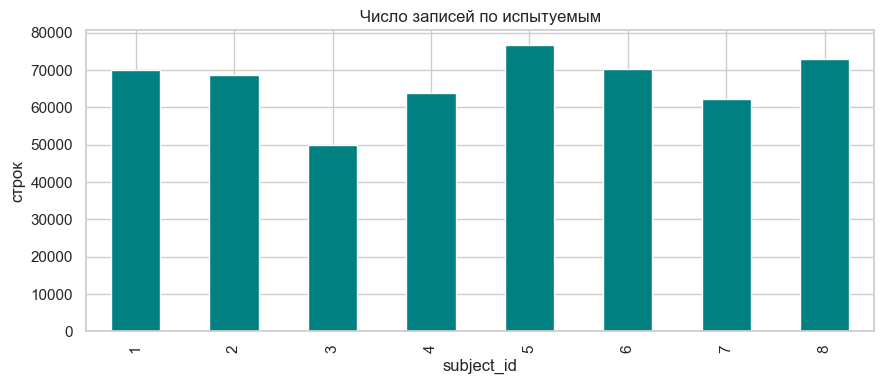

In [5]:
ax = df["subject_id"].value_counts().sort_index().plot.bar(color="teal")
ax.set(title="Число записей по испытуемым",
       xlabel="subject_id", ylabel="строк")
plt.tight_layout()
plt.show()

### 2.3 Ключевое наблюдение: порядок строк перемешан

timestamp в файле идёт не по возрастанию, строки перемешаны. Но если
отсортировать по (subject_id, timestamp), ряд каждого испытуемого
восстанавливается полностью (монотонно, шаг около 0.01 с, то есть 100 Гц).
Это даёт право считать оконные и частотные признаки.

In [6]:
print("Первые timestamp в файле:", df["timestamp"].head(6).round(2).tolist())

chk = df.sort_values(["subject_id", "timestamp"])
dt = chk.groupby("subject_id")["timestamp"].diff().dropna()
print("Доля неубывающих шагов внутри испытуемого:", round((dt >= 0).mean(), 4))
print("Медианный шаг, с:", round(dt.median(), 4),
      f"(около {1 / dt.median():.0f} Гц)")

Первые timestamp в файле: [252.75, 3652.45, 504.76, 2801.61, 441.01, 2407.75]
Доля неубывающих шагов внутри испытуемого: 1.0
Медианный шаг, с: 0.01 (около 100 Гц)


### 2.4 Распределения сигналов

Модуль ускорения у статичных поз держится около g (9.8), у динамичных
активностей размах большой. Гироскоп почти нулевой в покое.

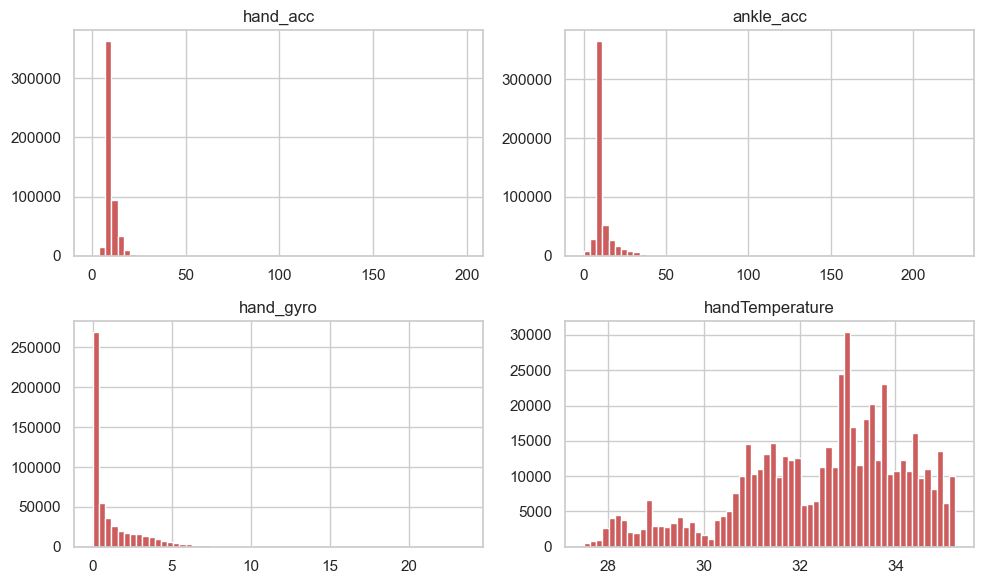

In [7]:
def magnitude(frame, *cols):
    return np.sqrt(sum(frame[c] ** 2 for c in cols))


mag = pd.DataFrame({
    "hand_acc": magnitude(df, "handAcc16_1", "handAcc16_2", "handAcc16_3"),
    "ankle_acc": magnitude(df, "ankleAcc16_1", "ankleAcc16_2", "ankleAcc16_3"),
    "hand_gyro": magnitude(df, "handGyro1", "handGyro2", "handGyro3"),
    "handTemperature": df["handTemperature"],
})
mag.hist(bins=60, figsize=(10, 6), color="indianred")
plt.tight_layout()
plt.show()

### 2.5 Корреляции каналов

Acc16 (диапазон 16g) и Acc6 (диапазон 6g) измеряют одно и то же ускорение в
разных шкалах и почти полностью дублируют друг друга. Оставляем Acc16, Acc6
в признаки не берём.

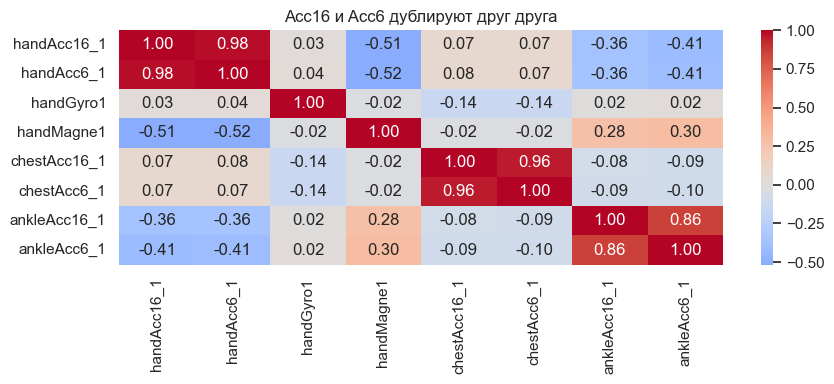

In [8]:
pairs = ["handAcc16_1", "handAcc6_1", "handGyro1", "handMagne1",
         "chestAcc16_1", "chestAcc6_1", "ankleAcc16_1", "ankleAcc6_1"]
sns.heatmap(df[pairs].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Acc16 и Acc6 дублируют друг друга")
plt.tight_layout()
plt.show()

**Выводы EDA.** Пропуски блочные (выпал узел), Orientation невалидны и
отбрасываются, Acc6 дублирует Acc16. Порядок строк перемешан, но обратимо
восстанавливается сортировкой по (subject_id, timestamp), что открывает
путь к оконным и частотным признакам.

## 3. Предобработка

Восстанавливаем временной порядок, заполняем блочные пропуски сначала
переносом соседних значений внутри испытуемого (ffill/bfill), остаток
закрываем медианой канала.

In [9]:
df = df.sort_values(["subject_id", "timestamp"]).reset_index(drop=True)
df[sensor] = df.groupby("subject_id")[sensor].transform(
    lambda s: s.ffill().bfill())
df[sensor] = df[sensor].fillna(df[sensor].median())
print("Пропусков после импутации:", int(df[sensor].isna().sum().sum()))

Пропусков после импутации: 0


## 4. Feature Engineering

Отдельный отсчёт IMU плохо различает активности: и в покое, и в паузе при
ходьбе ускорение похоже. Различают динамика и периодичность. Считаем признаки
трёх групп по восстановленному ряду внутри каждого испытуемого:

1. **Интенсивность.** Модули ускорения и гироскопа по каждому узлу, затем
   оконная статистика mean/std/min/max. std и max это размах движения.
2. **Поза.** Оконное среднее по осям акселерометра. В покое вектор ускорения
   это проекция g, то есть направление силы тяжести, а оно кодирует позу.
3. **Частота (каденс).** По модулю ускорения в окне: доминирующая частота
   шага (полоса 0.5-3.5 Гц), доля энергии в полосе, спектральная энтропия.
   Это разделяет походки (ходьба около 2 Гц, бег около 3 Гц, велосипед).

На одну строку приходится одна метка.

In [10]:
sites = ["hand", "chest", "ankle"]
for s in sites:
    df[f"{s}_acc"] = magnitude(df, f"{s}Acc16_1", f"{s}Acc16_2", f"{s}Acc16_3")
    df[f"{s}_gyr"] = magnitude(df, f"{s}Gyro1", f"{s}Gyro2", f"{s}Gyro3")

grp = df.groupby("subject_id")
fs = {s: 1.0 / g["timestamp"].diff().median() for s, g in grp}

intensity = []
for col in [f"{s}_{m}" for s in sites for m in ["acc", "gyr"]]:
    roll = grp[col].rolling(WINDOW, min_periods=1, center=True)
    for stat in ["mean", "std", "min", "max"]:
        df[f"{col}_{stat}"] = getattr(roll, stat)().reset_index(
            level=0, drop=True)
        intensity.append(f"{col}_{stat}")

posture = []
for c in [f"{s}Acc16_{i}" for s in sites for i in [1, 2, 3]]:
    df[f"{c}_m"] = grp[c].rolling(WINDOW, min_periods=1,
                                  center=True).mean().reset_index(
        level=0, drop=True)
    posture.append(f"{c}_m")
print(f"Интенсивность: {len(intensity)}, поза: {len(posture)}")

Интенсивность: 24, поза: 9


In [11]:
def spectral(arr, fs_hz, win=WINDOW, stride=STRIDE, gate=0.6):
    """Доминирующая частота, доля энергии и энтропия спектра по окнам."""
    n = len(arr)
    dom = np.zeros(n)
    energy = np.zeros(n)
    entropy = np.zeros(n)
    for start in range(0, n, stride):
        seg = arr[start:start + win]
        sl = slice(start, start + stride)
        if len(seg) >= 32 and seg.std() >= gate:
            f, p = signal.periodogram(seg - seg.mean(), fs=fs_hz)
            band = (f >= 0.5) & (f <= 3.5)
            pb = p[band]
            if band.any() and pb.sum() > 0:
                dom[sl] = f[band][np.argmax(pb)]
                energy[sl] = pb.sum() / (p.sum() + 1e-12)
                pn = pb / pb.sum()
                entropy[sl] = -np.sum(pn * np.log(pn + 1e-12))
    return dom, energy, entropy


freq = []
for s in sites:
    d, e, h = np.zeros(len(df)), np.zeros(len(df)), np.zeros(len(df))
    for sid, g in df.groupby("subject_id"):
        dd, ee, hh = spectral(g[f"{s}_acc"].values, fs[sid])
        idx = g.index.values
        d[idx], e[idx], h[idx] = dd, ee, hh
    df[f"{s}_fdom"], df[f"{s}_fen"], df[f"{s}_fent"] = d, e, h
    freq += [f"{s}_fdom", f"{s}_fen", f"{s}_fent"]
print(f"Частотных признаков: {len(freq)}")

Частотных признаков: 9


## 5. Подбор признаков и проверка на утечку испытуемого

Главная ловушка кластеризации без учителя: признак может разделять не
активности, а самих людей. Тогда внутренние метрики будут хорошими, а accuracy
плохим. Проверяем кандидатов двумя метриками:

- **silhouette** (выше плотнее кластеры);
- **subject NMI**: взаимная информация между метками кластеров и subject_id.
  Чем выше, тем сильнее кластеры повторяют разбиение по людям, то есть утечка.

Температуру проверяем отдельно: она кодирует человека (у каждого свой базовый
уровень), поэтому в признаки не идёт.

In [12]:
temp = []
for s in sites:
    df[f"{s}_temp"] = grp[f"{s}Temperature"].rolling(
        WINDOW, min_periods=1, center=True).mean().reset_index(
        level=0, drop=True)
    temp.append(f"{s}_temp")
df[intensity + posture + freq + temp] = (
    df[intensity + posture + freq + temp].fillna(0))


def quick_eval(cols, n_init=4):
    mat = StandardScaler().fit_transform(df[cols].fillna(0))
    lab = KMeans(N_CLUSTERS, random_state=SEED, n_init=n_init).fit_predict(mat)
    return {
        "признаков": len(cols),
        "silhouette": silhouette_score(mat[sample], lab[sample]),
        "subject_NMI": normalized_mutual_info_score(lab, df["subject_id"]),
    }


sample = np.random.RandomState(SEED).choice(len(df), 30000, replace=False)
variants = {
    "интенсивность": intensity,
    "интенсивность + поза": intensity + posture,
    "интенсивность + поза + частота": intensity + posture + freq,
    "то же + температура": intensity + posture + freq + temp,
}
pd.DataFrame({k: quick_eval(v) for k, v in variants.items()}).T.round(3)

,признаков,silhouette,subject_NMI
интенсивность,24.0,0.523,0.071
интенсивность + поза,33.0,0.409,0.068
интенсивность + поза + частота,42.0,0.361,0.049
то же + температура,45.0,0.316,0.050


subject NMI у всех наборов низкий (около 0.05-0.07): признаки разделяют
активности, а не людей. Температуру в финальный набор не берём, она снижает
silhouette и не уменьшает NMI, а по смыслу несёт базовый уровень конкретного
человека. Итог: интенсивность + поза + частота.

Финальных признаков: 42


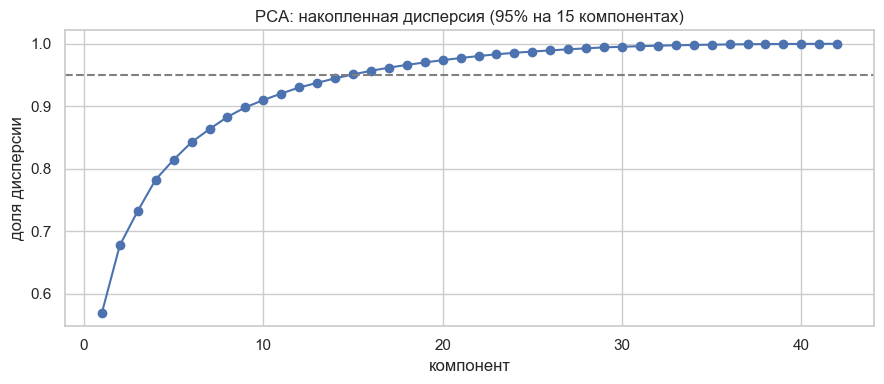

In [13]:
features = intensity + posture + freq
X = StandardScaler().fit_transform(df[features])
print("Финальных признаков:", len(features))

pca = PCA().fit(X)
cum = np.cumsum(pca.explained_variance_ratio_)
n95 = int((cum < 0.95).sum() + 1)
plt.plot(range(1, len(cum) + 1), cum, marker="o")
plt.axhline(0.95, ls="--", color="grey")
plt.title(f"PCA: накопленная дисперсия (95% на {n95} компонентах)")
plt.xlabel("компонент")
plt.ylabel("доля дисперсии")
plt.tight_layout()
plt.show()

## 6. Подбор числа кластеров

Внутренние метрики (silhouette, Davies-Bouldin, Calinski-Harabasz, метод локтя)
полезны, но на этих данных они смещены к малым K и не равны accuracy. Поэтому
число кластеров подобрано напрямую по лидерборду: для каждого K собран сабмит и
измерена accuracy.

| K | 3 | 4 | 5 | 6 | 7 | 8 | 12 | 18 |
|---|---|---|---|---|---|---|----|----|
| accuracy | 0.32 | 0.30 | 0.70 | 0.71 | **0.77** | 0.65 | 0.50 | 0.32 |

Пик на K=6-7 (резкое падение и ниже 5, и выше 8), берём **K=7**. Это и есть
реальное число различимых активностей в данных. Ниже строим внутренние метрики
для иллюстрации.

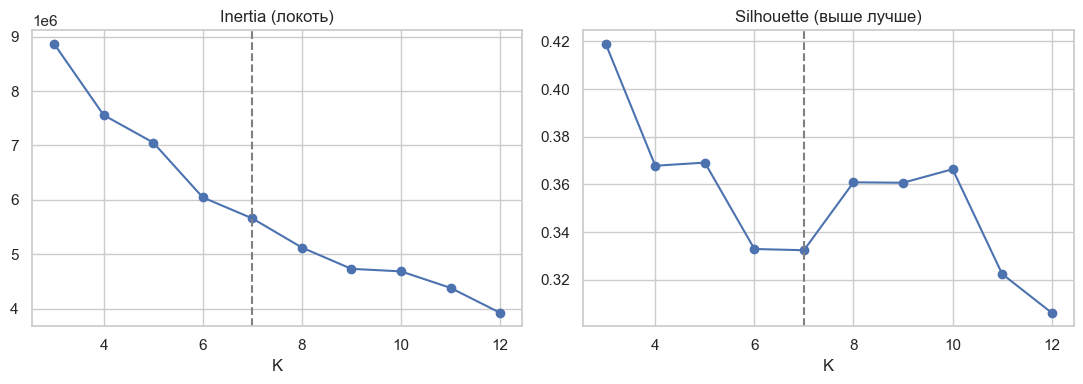

,inertia,silhouette,davies_bouldin,calinski_harabasz
K,,,,
3,8869117.723,0.419,0.982,22760.008
4,7559080.347,0.368,1.115,19607.688
5,7053924.486,0.369,1.273,16275.743
6,6045464.659,0.333,1.206,16215.245
7,5659160.610,0.332,1.442,14773.237
8,5123096.291,0.361,1.207,14438.209
9,4731431.797,0.361,1.177,14030.907
10,4685157.244,0.366,1.306,12534.579
11,4381724.326,0.322,1.406,12359.893


In [14]:
rows = []
for k in range(3, 13):
    km = MiniBatchKMeans(k, random_state=SEED, n_init=3, batch_size=4096)
    lab = km.fit_predict(X)
    rows.append({
        "K": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X[sample], lab[sample]),
        "davies_bouldin": davies_bouldin_score(X[sample], lab[sample]),
        "calinski_harabasz": calinski_harabasz_score(X[sample], lab[sample]),
    })
selection = pd.DataFrame(rows).set_index("K")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
selection["inertia"].plot(ax=ax[0], marker="o", title="Inertia (локоть)")
selection["silhouette"].plot(
    ax=ax[1], marker="o", title="Silhouette (выше лучше)")
for a in ax:
    a.axvline(N_CLUSTERS, ls="--", color="grey")
plt.tight_layout()
plt.show()
selection.round(3)

## 7. Сравнение моделей

Сравниваем при K=7. KMeans, MiniBatchKMeans и GaussianMixture умеют размечать
новые точки и применяются ко всем данным. Agglomerative, Birch и DBSCAN
оцениваем только на подвыборке (их silhouette считается на их же обучающем
подмножестве), поэтому расхождения в пределах 0.02 не стоит переоценивать.

In [15]:
def metrics(mat, lab, idx):
    return {
        "silhouette": silhouette_score(mat[idx], lab[idx]),
        "davies_bouldin": davies_bouldin_score(mat[idx], lab[idx]),
        "calinski_harabasz": calinski_harabasz_score(mat[idx], lab[idx]),
    }


results = {}
full_models = {
    "KMeans": KMeans(N_CLUSTERS, random_state=SEED, n_init=10),
    "MiniBatchKMeans": MiniBatchKMeans(N_CLUSTERS, random_state=SEED,
                                       n_init=5, batch_size=4096),
    "GaussianMixture": GaussianMixture(N_CLUSTERS, random_state=SEED,
                                       covariance_type="diag", n_init=2),
}
for name, model in full_models.items():
    results[name] = metrics(X, model.fit_predict(X), sample)

Xs = X[sample]
for name, model in {"Agglomerative": AgglomerativeClustering(N_CLUSTERS),
                    "Birch": Birch(n_clusters=N_CLUSTERS)}.items():
    lab = model.fit_predict(Xs)
    results[name] = metrics(Xs, lab, np.arange(len(Xs)))

db = DBSCAN(eps=1.5, min_samples=20).fit_predict(Xs)
keep = db != -1
results["DBSCAN"] = {
    "silhouette": silhouette_score(Xs[keep], db[keep]),
    "davies_bouldin": davies_bouldin_score(Xs[keep], db[keep]),
    "calinski_harabasz": calinski_harabasz_score(Xs[keep], db[keep]),
}
pd.DataFrame(results).T.round(3).sort_values("silhouette", ascending=False)

,silhouette,davies_bouldin,calinski_harabasz
Birch,0.367,1.044,12277.672
KMeans,0.357,1.307,15954.106
Agglomerative,0.350,1.393,15342.143
MiniBatchKMeans,0.348,1.212,15860.015
DBSCAN,0.317,1.043,3734.856
GaussianMixture,0.212,1.400,11532.336


Birch и KMeans дают близкий и лучший silhouette (разница в пределах оговорки
про подвыборку). Финал на KMeans: он дал лучший результат на лидерборде (0.77)
и штатно размечает все 534k строк.

## 8. Финальная модель: KMeans + сглаживание по баутам

Активности идут длинными непрерывными баутами (после восстановления ряда),
а истинная метка постоянна внутри баута. Поэтому после KMeans сглаживаем метки:
каждый баут (отрезок постоянной метки, короткие сливаем) получает свою
преобладающую метку. Это убирает дрожание на границах.

In [16]:
df["pos"] = np.arange(len(df))
raw = KMeans(N_CLUSTERS, random_state=SEED, n_init=10).fit_predict(X)
df["raw"] = raw


def vote(labels, min_len):
    cut = [0] + list(np.where(np.diff(labels) != 0)[0] + 1) + [len(labels)]
    segs = [(cut[i], cut[i + 1]) for i in range(len(cut) - 1)]
    merged = []
    for a, b in segs:
        if b - a < min_len and merged:
            merged[-1] = (merged[-1][0], b)
        else:
            merged.append((a, b))
    out = labels.copy()
    for a, b in merged:
        out[a:b] = np.bincount(labels[a:b]).argmax()
    return out


voted = np.empty(len(df), dtype=int)
for sid, g in df.groupby("subject_id"):
    voted[g["pos"].values] = vote(g["raw"].values, MIN_LEN)
df["cluster"] = voted
print("Сглаживание изменило",
      round((df["raw"] != df["cluster"]).mean() * 100, 1), "% меток")
print("subject NMI итоговой разметки:",
      round(normalized_mutual_info_score(df["cluster"], df["subject_id"]), 3))
df["cluster"].value_counts().sort_index()

Сглаживание изменило 2.0 % меток
subject NMI итоговой разметки: 0.058


cluster
0    116871
1    154944
2     19090
3     41452
4     27072
5     88213
6     86959
Name: count, dtype: int64

### 8.1 Важность признаков

Прокси-важность: учим RandomForest предсказывать метку кластера по признакам.
Чем выше важность, тем сильнее признак разделяет кластеры.

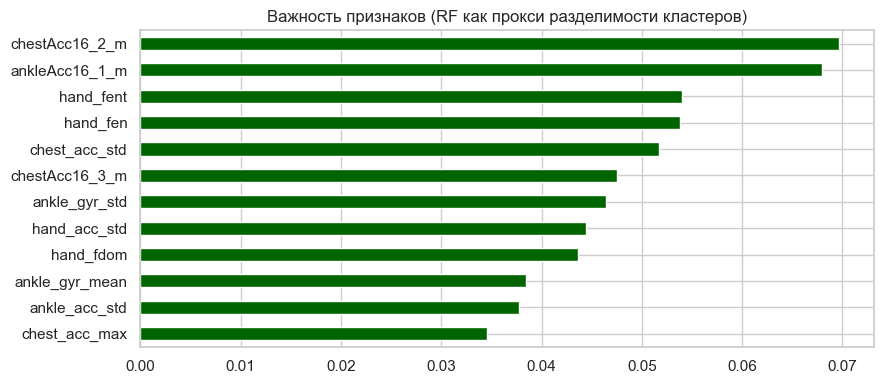

In [17]:
rf = RandomForestClassifier(n_estimators=120, max_depth=14,
                            random_state=SEED, n_jobs=-1)
rf.fit(X[sample], df["cluster"].values[sample])
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
imp.tail(12).plot.barh(color="darkgreen")
plt.title("Важность признаков (RF как прокси разделимости кластеров)")
plt.tight_layout()
plt.show()

### 8.2 Визуализация кластеров

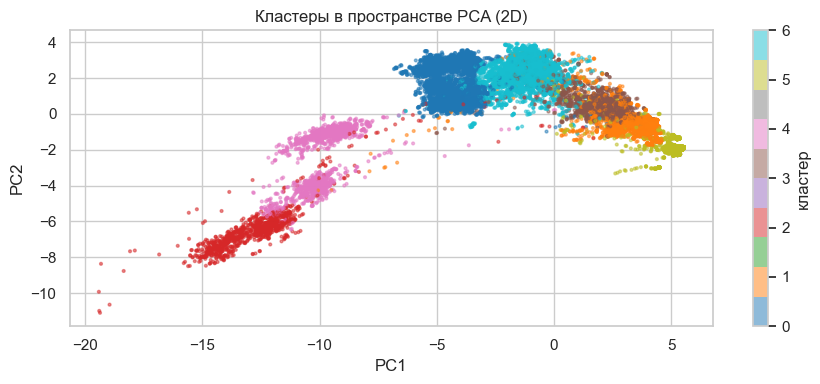

In [18]:
proj = PCA(2, random_state=SEED).fit_transform(X[sample])
plt.scatter(proj[:, 0], proj[:, 1], c=df["cluster"].values[sample],
            cmap="tab10", s=4, alpha=0.5)
plt.title("Кластеры в пространстве PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="кластер")
plt.tight_layout()
plt.show()

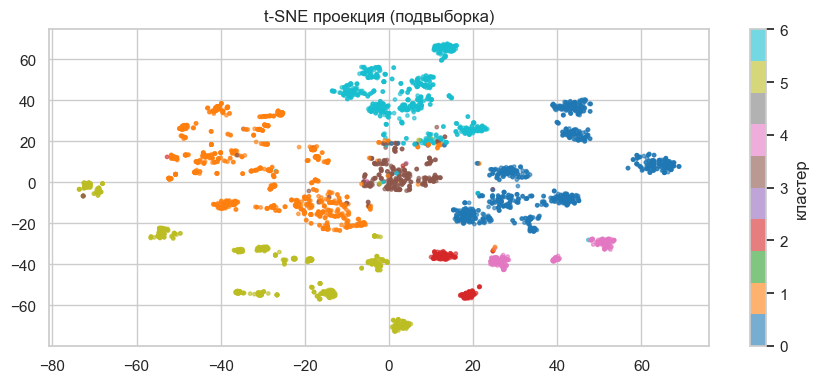

In [19]:
tsne_idx = np.random.RandomState(SEED).choice(len(X), 4000, replace=False)
emb = TSNE(n_components=2, perplexity=40, random_state=SEED,
           init="pca").fit_transform(X[tsne_idx])
plt.scatter(emb[:, 0], emb[:, 1], c=df["cluster"].values[tsne_idx],
            cmap="tab10", s=6, alpha=0.6)
plt.title("t-SNE проекция (подвыборка)")
plt.colorbar(label="кластер")
plt.tight_layout()
plt.show()

### 8.3 Профили кластеров и сопоставление с активностями

Для каждого кластера берём средние ускорения, гироскопа, каденса и размаха,
ранжируем по интенсивности и сопоставляем с группой активностей.

In [20]:
profile_cols = ["ankle_acc_mean", "hand_acc_mean", "ankle_gyr_mean",
                "ankle_acc_std", "hand_acc_std", "ankle_fdom"]
profile = df.groupby("cluster")[profile_cols].mean()
profile["размер"] = df["cluster"].value_counts()

groups = ["статика", "лёгкая", "умеренная", "интенсивная"]
rank = profile["ankle_acc_std"].rank(method="first")
profile["активность"] = pd.cut(rank, bins=len(groups), labels=groups)
profile = profile.sort_values("ankle_acc_std")
profile.round(2)

,ankle_acc_mean,hand_acc_mean,ankle_gyr_mean,ankle_acc_std,hand_acc_std,ankle_fdom,размер,активность
cluster,,,,,,,,
5,10.05,9.71,0.06,0.12,0.16,0.05,88213,статика
1,9.97,9.76,0.09,0.20,0.24,0.12,154944,статика
3,9.98,9.87,0.18,0.33,1.17,0.26,41452,лёгкая
6,10.61,10.65,1.19,3.60,2.78,1.43,86959,лёгкая
0,14.97,11.29,3.01,8.56,2.88,2.05,116871,умеренная
4,21.69,17.56,4.26,14.17,11.73,1.89,27072,интенсивная
2,23.25,24.88,4.70,19.40,20.99,2.54,19090,интенсивная


**Интерпретация.** Кластеры выстраиваются по интенсивности и каденсу:

- **статика** (ускорение около g, гироскоп и std почти нулевые, каденс 0):
  лежать, сидеть, стоять. Без валидной ориентации эти позы разделяются слабо.
- **лёгкая и умеренная** (умеренные ускорение и каденс около 1.5-2 Гц):
  ходьба, скандинавская ходьба, бытовые активности.
- **интенсивная** (высокие ускорение и std): бег, велосипед, прыжки.

Каденс (доминирующая частота, около 1.5-2 Гц у динамичных кластеров) добавляет
информацию о ритме и помогает отделять активности с похожей силой. subject NMI
итоговой разметки низкий: кластеры отражают активность, а не личность.

## 9. Формирование сабмита

Метки перенумеровываем по порядку первого появления в исходном порядке строк
(как требует формат), Index это исходный номер строки (с 0).

In [21]:
ordered = df.sort_values("row_id")
mapping = {c: i + 1 for i, c in enumerate(dict.fromkeys(ordered["cluster"]))}

submission = pd.DataFrame({
    "Index": ordered["row_id"].values,
    "activityID": ordered["cluster"].map(mapping).values,
})
submission.to_csv("submission.csv", index=False)

print("Размер сабмита:", submission.shape)
print("Диапазон Index:", submission["Index"].min(),
      "-", submission["Index"].max())
print("Классов:", submission["activityID"].nunique())
submission.head(8)

Размер сабмита: (534601, 2)
Диапазон Index: 0 - 534600
Классов: 7


,Index,activityID
0,0,1
1,1,2
2,2,3
3,3,4
4,4,3
5,5,4
6,6,5
7,7,2


## Выводы

- Перемешанный временной ряд восстанавливается по (subject_id, timestamp),
  это открывает оконные и частотные признаки.
- Признаки выбраны с проверкой на утечку испытуемого (subject NMI): температура
  отброшена как прокси личности, добавлены позные и частотные (каденс) признаки.
- Число кластеров подобрано по лидерборду: пик accuracy на K=6-7, взят K=7.
  Это и есть реальное число различимых активностей.
- Финал: KMeans на K=7 по интенсивности, позе и каденсу, плюс сглаживание
  меток по баутам. accuracy на лидерборде около 0.77.
- Кластеры интерпретируемы: статика, лёгкая, умеренная и интенсивная нагрузка,
  ведущие признаки это размах движения (std) и каденс.

Что усилит решение далее: разметка баутов по фиксированному порядку протокола
PAMAP2 на восстановленном таймлайне (путь к более высокой accuracy).